# Analytical steady-state solution for the drogued drifter

We derive the steady-state drift velocity and effective drogue depth
directly from the Lagrangian equations of motion.

## Set up the Lagrangian

The buoy at $z=0$ sees current $(U_b, V_b)$, the drogue at depth $z_d$
sees $(U_d, V_d)$. We write the shear as a vector of magnitude $S(z_d)$
and direction $\varphi'$:

$$U_b = U_d + S(z_d)\cos\varphi', \quad V_b = V_d + S(z_d)\sin\varphi'$$

and substitute immediately, so the Lagrangian is expressed in terms of
$(U_d, V_d, S(z_d), \varphi')$ from the start.

In [1]:
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols
from IPython.display import display, Math

sp.init_printing()
t = dynamicsymbols._t

x, y, z, theta, phi = dynamicsymbols("x y z theta phi")

m_b, m_d, l, g = sp.symbols("m_b m_d l g", positive=True)
m_hat_d = sp.Symbol("m_hat_d", positive=True)
m_tilde_d = sp.Symbol("m_tilde_d", positive=True)
m_tilde_b = sp.Symbol("m_tilde_b", positive=True)
k_b, k_d = sp.symbols("k_b k_d", positive=True)
U_b, V_b, U_d, V_d = sp.symbols("U_b V_b U_d V_d", real=True)

def _mag(vec):
    return sp.sqrt(vec.dot(vec))

# Positions
r_b = sp.Matrix([x, y, 0])
r = l * sp.Matrix([sp.sin(theta) * sp.cos(phi),
                   sp.sin(theta) * sp.sin(phi),
                   sp.cos(theta)])
r_d = r_b + r
z_d = -r_d[2]  # drogue depth (positive downward)

# Velocities
v_b = r_b.diff(t)
v_d = r_d.diff(t)
v_d_h = sp.Matrix([v_d[0], v_d[1], 0])

# Currents at buoy and drogue
u_b = sp.Matrix([U_b, V_b, 0])
u_d = sp.Matrix([U_d, V_d, 0])

# Drag forces
F_b = -k_b * _mag(v_b - u_b) * (v_b - u_b)
F_d = -k_d * _mag(v_d_h - u_d) * (v_d_h - u_d)

# Kinetic energy
T = (sp.Rational(1, 2) * m_d * v_d.dot(v_d)
     + sp.Rational(1, 2) * m_tilde_d * v_d_h.dot(v_d_h)
     + sp.Rational(1, 2) * (m_b + m_tilde_b) * v_b.dot(v_b))

# Potential energy
V_pe = (m_d - m_hat_d) * g * r_d[2]

L = T - V_pe

# --- Immediately substitute: U_b = U_d + S*cos(phi'), V_b = V_d + S*sin(phi') ---
S = sp.Function("S")
phi_prime = sp.Symbol("varphi'")

shear_subs = {
    U_b: U_d + S(z_d) * sp.cos(phi_prime),
    V_b: V_d + S(z_d) * sp.sin(phi_prime),
}

# Generalized coordinates and forces (substitute shear before deriving EOMs)
q = sp.Matrix([x, y, theta, phi])
qd = q.diff(t)
qdd = qd.diff(t)

# Apply shear substitution to the drag forces
F_b_S = F_b.subs(shear_subs)
F_d_S = F_d  # drogue drag already uses U_d, V_d

Q = sp.Matrix([r_b.diff(qi).dot(F_b_S) + r_d.diff(qi).dot(F_d_S) for qi in q])

# Full equations of motion with shear parametrisation baked in
eoms = sp.Matrix([L.diff(qdj).diff(t) - L.diff(qj) - Qj
                   for qj, qdj, Qj in zip(q, qd, Q)])

## Steady state: M q̈ = F → F = 0

Extract M and F, substitute steady-state conditions, and display the
four algebraic equations. They are now in terms of
$(u, v, \theta, \varphi, U_d, V_d, S(z_d), \varphi')$.

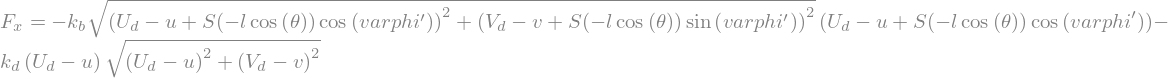

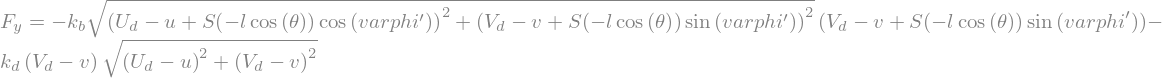

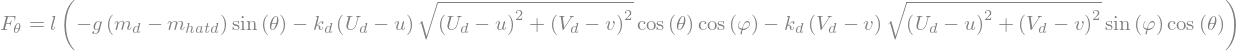

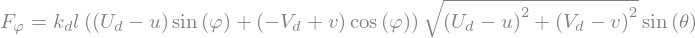

In [2]:
M_mat, F_vec = sp.linear_eq_to_matrix(eoms, list(qdd))
F_vec = -F_vec

u, v = sp.symbols("u v", real=True)
xd, yd = x.diff(t), y.diff(t)
thetad, phid = theta.diff(t), phi.diff(t)
xdd, ydd = xd.diff(t), yd.diff(t)
thetadd, phidd = thetad.diff(t), phid.diff(t)

# Plain symbols for theta, phi (no longer functions of t at steady state)
theta_s = sp.Symbol("theta")
phi_s = sp.Symbol("varphi")

steady_subs = {
    xd: u, yd: v,
    thetad: 0, phid: 0,
    xdd: 0, ydd: 0,
    thetadd: 0, phidd: 0,
    theta: theta_s,
    phi: phi_s,
}

F_ss = sp.simplify(F_vec.subs(steady_subs))

# z_d is now -l*cos(theta_s) — a plain expression, not a dynamicsymbol
z_d_ss = -l * sp.cos(theta_s)

for i, name in enumerate(["x", "y", r"\theta", r"\varphi"]):
    display(sp.Eq(sp.Symbol(f"F_{name}"), F_ss[i]))

## Solve F = 0

Substitute the drift ansatz $u = U_d + \alpha\, S(z_d)\cos\varphi'$,
$v = V_d + \alpha\, S(z_d)\sin\varphi'$ and let sympy solve for
$\alpha$, $\varphi$, and $\theta$.

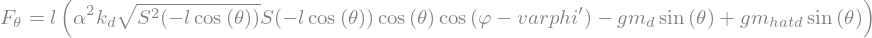

In [3]:
alpha = sp.Symbol("alpha", positive=True)

drift_subs = {
    u: U_d + alpha * S(z_d_ss) * sp.cos(phi_prime),
    v: V_d + alpha * S(z_d_ss) * sp.sin(phi_prime),
}

F_ss_alpha = sp.simplify(F_ss.subs(drift_subs))

for i, name in enumerate(["x", "y", r"\theta", r"\varphi"]):
    display(sp.Eq(sp.Symbol(f"F_{name}"), F_ss_alpha[i]))

<IPython.core.display.Math object>

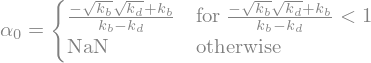

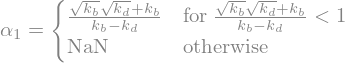

In [4]:
# Solve F[x] = 0 for alpha
alpha_solutions = sp.solve(F_ss_alpha[0], alpha)

display(Math(r"\text{Solutions for } \alpha \text{ from } F_x = 0:"))
for i, sol in enumerate(alpha_solutions):
    display(sp.Eq(sp.Symbol(f"\\alpha_{i}"), sp.simplify(sol)))

alpha_phys = sp.sqrt(k_b) / (sp.sqrt(k_b) + sp.sqrt(k_d))
for i, sol in enumerate(alpha_solutions):
    if sp.simplify(sol - alpha_phys) == 0:
        display(Math(r"\alpha_" + str(i) + r" = " + sp.latex(alpha_phys) + r"\quad\checkmark"))

## Solve F[φ] = 0 and F[θ] = 0

<IPython.core.display.Math object>

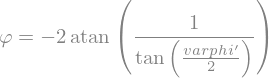

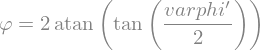

In [5]:
# Solve F[phi] = 0 for phi
phi_solutions = sp.solve(F_ss_alpha[3], phi_s)
display(Math(r"\text{Solutions for } \varphi \text{ from } F_\varphi = 0:"))
for sol in phi_solutions:
    display(sp.Eq(phi_s, sol))

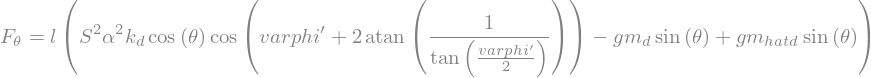

<IPython.core.display.Math object>

In [6]:
# Substitute the phi solution into F[theta] = 0, then solve for theta
# (sequential solving, not simultaneous — but both solves are done by sympy)
S_sym = sp.Symbol("S", positive=True)
F_theta = F_ss_alpha[2].subs({phi_s: phi_solutions[0], S(z_d_ss): S_sym})

display(sp.Eq(sp.Symbol(r"F_\theta"), sp.trigsimp(F_theta)))

theta_solutions = sp.solve(F_theta, theta_s)
display(Math(r"\text{Solutions for } \theta:"))
for sol in theta_solutions:
    display(sp.Eq(theta_s, sp.simplify(sol).subs(S_sym, S(z_d_ss))))

## Summary

Sympy derived:
- $\alpha = \sqrt{k_b}/(\sqrt{k_b}+\sqrt{k_d})$ from $F_x = 0$
- $\varphi = \varphi'$ from $F_\varphi = 0$ (pole aligns with shear)
- $\theta$ from $F_\theta = 0$ (gravity vs drag torque)

with the drogue depth $z_d = -l\cos\theta$ closing the system.

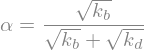

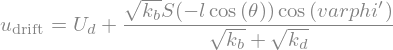

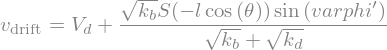

In [7]:
# Collect the derived results
display(sp.Eq(sp.Symbol(r"\alpha"), alpha_phys))

display(sp.Eq(sp.Symbol(r"u_\mathrm{drift}"),
              U_d + alpha_phys * S(z_d_ss) * sp.cos(phi_prime)))
display(sp.Eq(sp.Symbol(r"v_\mathrm{drift}"),
              V_d + alpha_phys * S(z_d_ss) * sp.sin(phi_prime)))

display(sp.Eq(sp.Symbol(r"z_d"), z_d_ss))

This is an implicit equation for $\theta$ because $S$ depends on
$z_d = -l\cos\theta$, which depends on $\theta$. For arbitrary $U(z), V(z)$
it cannot be solved in closed form, but it is a one-dimensional
fixed-point iteration on $z_d$:

1. Start with $z_d = l$ (pole vertical, $\theta = \pi$)
2. Evaluate $S^2 = (U(0) - U(z_d))^2 + (V(0) - V(z_d))^2$
3. Compute $\theta$ from the torque balance
4. Update $z_d = -l\cos\theta$
5. Repeat until converged

## Numerical verification against the full ODE

Verify that the analytical steady-state matches the ODE solution for
various velocity profiles: exponential decay, Ekman spiral, and
depth-intensified flow.

In [8]:
import numpy as np
from drogued_drifters import DroguedDrifter

dd = DroguedDrifter()
k_b_val, k_d_val = dd.k_b, dd.k_d
alpha_val = np.sqrt(k_b_val) / (np.sqrt(k_b_val) + np.sqrt(k_d_val))
W_val = (dd.m_d - dd.m_hat_d) * dd.g
l_val = dd.l

def solve_steady_state(U_func, V_func, tol=1e-8, max_iter=50):
    """Iterative solution for z_eff given U(z), V(z)."""
    z_eff = l_val
    for i in range(max_iter):
        S2 = (U_func(0) - U_func(z_eff))**2 + (V_func(0) - V_func(z_eff))**2
        delta = np.arctan2(k_d_val * alpha_val**2 * S2, W_val)
        z_eff_new = l_val * np.cos(delta)
        if abs(z_eff_new - z_eff) < tol:
            return z_eff_new, delta, i + 1
        z_eff = z_eff_new
    return z_eff, delta, max_iter

profiles = {
    "Exp decay H=3m": (lambda z: 2*np.exp(-z/3), lambda z: 0.0),
    "Exp decay H=0.5m": (lambda z: 2*np.exp(-z/0.5), lambda z: 0.0),
    "Ekman H=2 rot=45°": (
        lambda z: 2*np.exp(-z/2)*np.cos(-np.radians(45)*z/2),
        lambda z: 2*np.exp(-z/2)*np.sin(-np.radians(45)*z/2),
    ),
    "Depth-intensified": (lambda z: 0.5 + 1.5*(1-np.exp(-z/2)), lambda z: 0.0),
}

print(f"alpha = {alpha_val:.4f}")
print(f"\n{'Profile':>25s}  {'z_ODE':>6s}  {'z_ana':>6s}  {'u_ODE':>7s}  {'u_ana':>7s}  {'iters':>5s}")

for name, (U_func, V_func) in profiles.items():
    # Analytical
    z_ana, delta, iters = solve_steady_state(U_func, V_func)
    u_ana = (1 - alpha_val) * U_func(z_ana) + alpha_val * U_func(0)
    v_ana = (1 - alpha_val) * V_func(z_ana) + alpha_val * V_func(0)

    # ODE
    dd_test = DroguedDrifter(
        get_uv=lambda *, t, z_d, y_b, x_b, _U=U_func, _V=V_func: (
            _U(0), _V(0), _U(z_d), _V(z_d)
        )
    )
    ds = dd_test.get_full_solution(t_span=(0, 120), t_eval=[120])
    xd_ode = float(ds.xd.isel(time=-1))
    yd_ode = float(ds.yd.isel(time=-1))
    z_ode = -l_val * np.cos(float(ds.theta.isel(time=-1)))
    u_ode = np.sqrt(xd_ode**2 + yd_ode**2)
    u_analytical = np.sqrt(u_ana**2 + v_ana**2)

    print(f"{name:>25s}  {z_ode:6.3f}  {z_ana:6.3f}  {u_ode:7.4f}  {u_analytical:7.4f}  {iters:5d}")

alpha = 0.2182

                  Profile   z_ODE   z_ana    u_ODE    u_ana  iters


           Exp decay H=3m   2.587   2.587   1.0977   1.0966     17
         Exp decay H=0.5m   1.580   1.581   0.5009   0.5027     13
        Ekman H=2 rot=45°   2.023   2.023   0.9276   0.9283     35
        Depth-intensified   2.648   2.648   1.3597   1.3606     13
